In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1015. Fire Sufficient Similarity/P1015.3. Analyses/P1015.3.3. Cluster Analysis/Output'
cur_date = '031926'

library(readxl)
library(tidyverse)
library(reshape2)
# library(vegan)
# library(ecodist)
library(ComplexHeatmap)
#library(circlize)
library(data.table)

# reading in files
full_df = data.frame(read_excel("Input/Processed_Data_022826.xlsx")) %>%
    # removing records that weren't measured
    filter(Value2 == 'Present') %>%
    select(-Value2)
wf_info_df = data.frame(read_excel("Input/Study_Info_WF_012226.xlsx", sheet = 2))[,1:12]
ws_info_df = data.frame(read_excel("Input/Study_Info_WS_012226.xlsx", sheet = 2))[,1:15]
ws_info_df$HAWC_ID = as.character(ws_info_df$HAWC_ID)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Loading required package: grid

ComplexHeatmap version 2.24.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. C

In [2]:
head(full_df)
head(wf_info_df)
head(ws_info_df)

,HAWC_ID,Metric,Sample,Study,Sample_Number,Study_Sample_ID,DTXSID,Value,Class,Name
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,Ca,8.59618976,Metal,Calcium
2,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,Ni,0.54649640,Metal,Nickel
3,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID0022432,0.07997538,PAH,Chrysene
4,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID3024104,0.15574923,PAH,Fluoranthene
5,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,DTXSID6024254,0.07724300,PAH,Phenanthrene
6,1289889,Volume,WF,Scaramboni et al. 2024,3,1289889_3,Cu,6.78135971,Metal,Copper


,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Fire_Type,Location,PM_Size,Sample_Matrix,Fuel_Species,Fuel_Type
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,Natural,Wooded,NA,Ash,Eucalyptus,Hardwood
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,Natural,Wooded,NA,Ash,Pine,Softwood


,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,429174,Arif et al. 2017,1,429174_1,PAH,Weight,Boiler,NA,Very fine,PM,Mixed,Smoke,Softwood,Medium,Chip
2,429174,Arif et al. 2017,2,429174_2,PAH,Weight,Boiler,NA,Very fine,PM,Beech,Smoke,Hardwood,Medium,Chip
3,298566,Jalava et al. 2010,1,298566_1,PAH,Weight,Masonry heater,Normal,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
4,298566,Jalava et al. 2010,2,298566_2,PAH,Weight,Masonry heater,Normal,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
5,298566,Jalava et al. 2010,3,298566_3,PAH,Weight,Masonry heater,Smoldering,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log
6,298566,Jalava et al. 2010,4,298566_4,PAH,Weight,Masonry heater,Smoldering,Very fine,PM,Birch,Flue gas,Hardwood,Medium,Log


In [3]:
# creating 1 df that contains all the meta data
ws_info_df = ws_info_df %>%
    mutate(Sample = 'WS', Fire_Type = NA, Location = NA)
wf_info_df = wf_info_df %>%
    mutate(Sample = 'WF', Source = NA, Combustion_Condition = NA, Sample_Origin = NA, Efficiency = NA, Fuel_Size = NA) 
wf_info_df = wf_info_df[,colnames(ws_info_df)]

info_df = rbind(wf_info_df, ws_info_df)
head(info_df)

,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size,Sample,Fire_Type,Location
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,NA,NA,NA,Ash,Pine,NA,Softwood,NA,NA,WF,Natural,Wooded


In [4]:
# splitting based on metric
metric_split = full_df %>%
    group_by(Metric) %>%
    group_split()

vol_df = metric_split[[1]]
weight_df = metric_split[[2]]

In [29]:
# converting to a wide format
wider_vol_df = vol_df %>%
    select(-c("DTXSID", "Class")) %>%
    # removing outliers
    #filter(SampleID %notin% vol_outliers) %>%
    pivot_wider(names_from = "Name", values_from = "Value") %>%
    column_to_rownames(var = "Study_Sample_ID")

wider_weight_df = weight_df %>%
    select(-c("DTXSID", "Class")) %>%
    pivot_wider(names_from = "Name", values_from = "Value", id_cols = Study_Sample_ID) %>%
    column_to_rownames(var = "Study_Sample_ID")

head(wider_vol_df)

,HAWC_ID,Metric,Sample,Study,Sample_Number,Calcium,Nickel,Chrysene,Fluoranthene,Phenanthrene,Copper,Lead,Iron,Potassium,Manganese,Pyrene,Strontium,Zinc
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1289889_3,1289889,Volume,WF,Scaramboni et al. 2024,3,8.596190,0.5464964,0.079975377,0.1557492,0.0772430,6.781360,0.8718436,7.247928,9.491853,1.448901,0.1123665,NA,NA
1289889_1,1289889,Volume,WF,Scaramboni et al. 2024,1,2.931926,0.6959938,0.409255147,0.5350576,0.2116353,6.221104,2.9164766,9.609179,9.612868,3.666757,0.5300707,NA,NA
1289889_2,1289889,Volume,WF,Scaramboni et al. 2024,2,2.931926,0.2986583,0.304511042,0.3010023,0.1137005,4.887525,2.0426443,8.629357,9.459432,2.558268,0.3459640,NA,NA
1426391_1,1426391,Volume,WF,O'Malley et al. 2024,1,NA,NA,0.648005180,2.1890338,5.1043367,NA,NA,NA,NA,NA,3.0959244,NA,NA
1426391_3,1426391,Volume,WF,O'Malley et al. 2024,3,NA,NA,0.014098156,0.2785796,1.7268312,NA,NA,NA,NA,NA,0.2326608,NA,NA
1426391_4,1426391,Volume,WF,O'Malley et al. 2024,4,NA,NA,0.006764782,0.1273691,1.9634741,NA,NA,NA,NA,NA,0.2939590,NA,NA


In [6]:
#analytes = colnames(wider_vol_df)[6:ncol(wider_vol_df)]

# scaling each col, but keeping the NAs as NAs
scale_column <- function(x) {
    avg <- mean(x, na.rm = TRUE)
    sdv <- stats::sd(x, na.rm = TRUE)

    # If constant or all NA, return zeros where not NA (keeps NA where NA)
    if (is.na(sdv) || sdv == 0) {
        out <- ifelse(is.na(x), NA, 0)
    } else {
        out <- (x - avg) / sdv
  }
  return(out)
}
vol_mat_scaled = apply(as.matrix(wider_vol_df[6:ncol(wider_vol_df)]), 2, scale_column)
weight_mat_scaled = apply(as.matrix(wider_weight_df[6:ncol(wider_weight_df)]), 2, scale_column)

head(vol_mat_scaled)

,Calcium,Nickel,Chrysene,Fluoranthene,Phenanthrene,Copper,Lead,Iron,Potassium,Manganese,Pyrene,Strontium,Zinc
1289889_3,-1.459639,-1.842839,-0.5634027,-0.5477155,-0.61936632,-0.3512802,-1.967267,-1.902409,-1.931819,-2.350044,-0.5479620,NA,NA
1289889_1,-2.705319,-1.791570,-0.5168284,-0.4982955,-0.60311977,-0.5665714,-1.295941,-1.083761,-1.896873,-1.822390,-0.4936474,NA,NA
1289889_2,-2.705319,-1.927833,-0.5316437,-0.5287905,-0.61495901,-1.0790294,-1.582851,-1.423466,-1.941181,-2.086112,-0.5175871,NA,NA
1426391_1,NA,NA,-0.4830589,-0.2827991,-0.01164601,NA,NA,NA,NA,NA,-0.1600062,NA,NA
1426391_3,NA,NA,-0.5727206,-0.5317120,-0.41994925,NA,NA,NA,NA,NA,-0.5323200,NA,NA
1426391_4,NA,NA,-0.5737578,-0.5514132,-0.39134173,NA,NA,NA,NA,NA,-0.5243493,NA,NA


In [7]:
cluster_analyte_order = function (scaled_matrix){

    }
## ---- Identify clusterable analytes ----
non_na_counts <- colSums(!is.na(mat_scaled))
col_sds <- apply(mat_scaled, 2, function(x) stats::sd(x, na.rm = TRUE))
good_cols <- which(non_na_counts >= 2 & !is.na(col_sds) & col_sds > 0)
bad_cols  <- setdiff(seq_len(ncol(mat_scaled)), good_cols)

## ---- Cluster good analytes using Spearman correlation ----
clustered_good <- character(0)
if (length(good_cols) >= 2) {
  col_cor <- suppressWarnings(cor(
    mat_scaled[, good_cols, drop = FALSE],
    use = "pairwise.complete.obs",
    method = "spearman"
  ))
  # Replace NAs (e.g., non-overlapping pairs), set diagonal to 1, enforce symmetry
  col_cor[is.na(col_cor)] <- 0
  diag(col_cor) <- 1
  col_cor <- (col_cor + t(col_cor)) / 2

  # Convert to a proper square distance matrix WITHOUT pmax()
  col_dist_mat <- 1 - col_cor
  col_dist_mat[col_dist_mat < 0] <- 0  # clamp tiny negatives due to numerical noise
  diag(col_dist_mat) <- 0

  # Sanity checks to avoid your previous error
  stopifnot(is.matrix(col_dist_mat))
  stopifnot(nrow(col_dist_mat) == ncol(col_dist_mat))

  # Build a 'dist' and cluster
  col_dist <- as.dist(col_dist_mat)
  col_hc <- hclust(col_dist, method = "average")
  clustered_good <- colnames(mat_scaled)[good_cols][col_hc$order]

} else if (length(good_cols) == 1) {
  clustered_good <- colnames(mat_scaled)[good_cols]
}

## ---- Final column order: clustered good analytes, then bad ones ----
final_order <- c(clustered_good, colnames(mat_scaled)[bad_cols])

In [11]:
head(info_df)

,HAWC_ID,Study,Sample_Number,Study_Sample_ID,Class,Metric,Source,Combustion_Condition,PM_Size,Sample_Matrix,Fuel_Species,Sample_Origin,Fuel_Type,Efficiency,Fuel_Size,Sample,Fire_Type,Location
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1289737,Campbell et al. 2024,1,1289737_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
2,1289739,Campos et al. 2019,1,1289739_1,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
3,1289739,Campos et al. 2019,2,1289739_2,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
4,1289739,Campos et al. 2019,3,1289739_3,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
5,1289739,Campos et al. 2019,4,1289739_4,PAH,Weight,NA,NA,NA,Ash,Eucalyptus,NA,Hardwood,NA,NA,WF,Natural,Wooded
6,1289739,Campos et al. 2019,5,1289739_5,PAH,Weight,NA,NA,NA,Ash,Pine,NA,Softwood,NA,NA,WF,Natural,Wooded


In [8]:
# reordering the cols to match the cluster order
final_mat = mat_scaled[,final_order]
head(final_mat)

annotation_vol_col_df = wider_vol_df %>%
    select(Sample) %>%
    rownames_to_column(var = "Study_Sample_ID") %>%
    left_join(info_df[,c(4,6,9:11,13,16:18)]) %>%
    select(-Metric) %>%
    unique() %>%
    remove_rownames() %>%
    column_to_rownames(var = "Study_Sample_ID") %>%
    mutate(Sample = ifelse(Sample == "WS", "Woodsmoke",
                                  ifelse(Sample == "WF", "Wildfire", Sample)))    
  
annotation_vol_row_df = unique(vol_df[,c("Class", "Name")]) %>%
    column_to_rownames(var = "Name")

# rearranging row names so that they're in the same order
annotation_vol_row_df = annotation_vol_row_df[final_order,, drop = FALSE]

head(annotation_vol_col_df)
head(annotation_vol_row_df)

,Strontium,Calcium,Manganese,Nickel,Copper,Potassium,Zinc,Iron,Phenanthrene,Fluoranthene,Pyrene,Chrysene,Lead
1289889_3,NA,-1.459639,-2.350044,-1.842839,-0.3512802,-1.931819,NA,-1.902409,-0.61936632,-0.5477155,-0.5479620,-0.5634027,-1.967267
1289889_1,NA,-2.705319,-1.822390,-1.791570,-0.5665714,-1.896873,NA,-1.083761,-0.60311977,-0.4982955,-0.4936474,-0.5168284,-1.295941
1289889_2,NA,-2.705319,-2.086112,-1.927833,-1.0790294,-1.941181,NA,-1.423466,-0.61495901,-0.5287905,-0.5175871,-0.5316437,-1.582851
1426391_1,NA,NA,NA,NA,NA,NA,NA,NA,-0.01164601,-0.2827991,-0.1600062,-0.4830589,NA
1426391_3,NA,NA,NA,NA,NA,NA,NA,NA,-0.41994925,-0.5317120,-0.5323200,-0.5727206,NA
1426391_4,NA,NA,NA,NA,NA,NA,NA,NA,-0.39134173,-0.5514132,-0.5243493,-0.5737578,NA


Joining with `by = join_by(Study_Sample_ID, Sample)`


,Sample,PM_Size,Sample_Matrix,Fuel_Species,Fuel_Type,Fire_Type,Location
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1289889_3,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1289889_1,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1289889_2,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_1,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_3,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded
1426391_4,Wildfire,Fine,Air,NA,NA,Natural,Urban and wooded


,Class
,<chr>
Strontium,Metal
Calcium,Metal
Manganese,Metal
Nickel,Metal
Copper,Metal
Potassium,Metal


In [11]:
# obtaining color palette
fall_colors = rev(palette(hcl.colors(10, "PiYG")))

Loading required namespace: gridtext



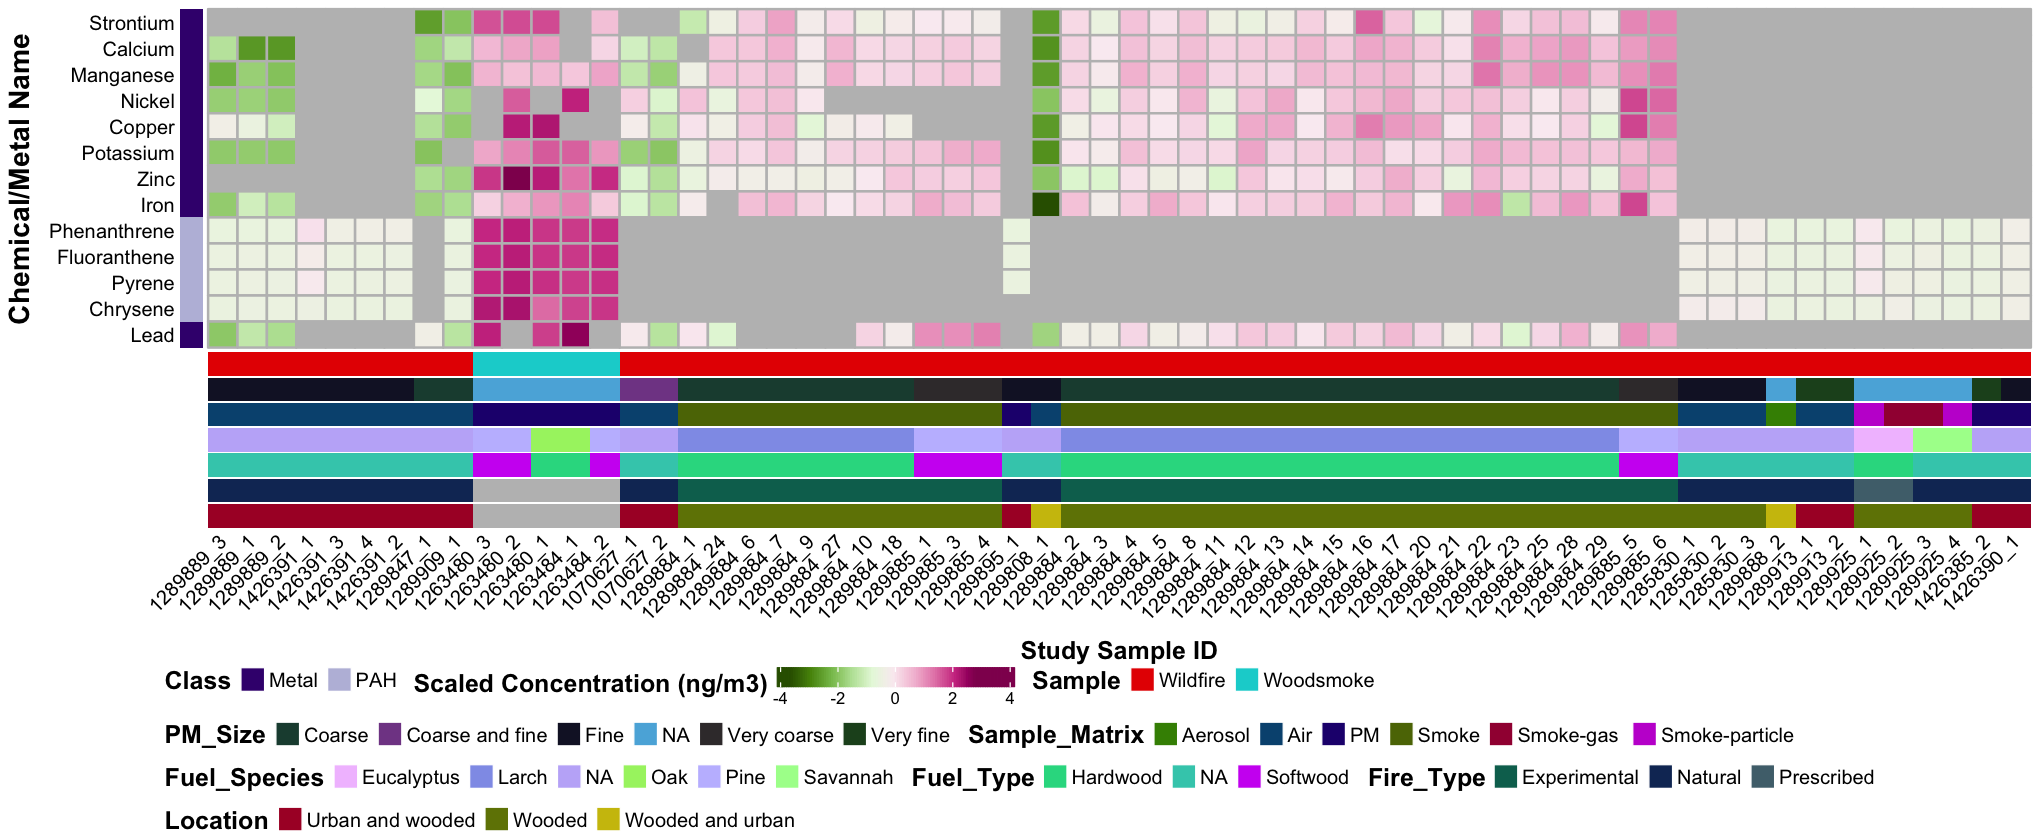

In [12]:
options(repr.plot.width=17, repr.plot.height=7) #changing size
ht = Heatmap(t(final_mat), rect_gp = gpar(col = "gray", lwd = 2), # cell border color
     cluster_rows = FALSE,  cluster_columns = FALSE, 
     col = fall_colors, # changing colors

    # legend title
    heatmap_legend_param = list(title = gt_render("Scaled\nConcentration\n(ng/m3)"), 
              title_position = "leftcenter", direction = "horizontal", legend_width = unit(5, "cm"), 
              title_gp = gpar(fontsize = 15, fontface = "bold")),
   # adding axes titles
    column_title = "Study Sample ID", column_title_side = "bottom", 
    column_title_gp = gpar(fontsize = 15, fontface = "bold"),
    column_names_gp = gpar(fontsize = 12), column_names_rot = 45,
    row_title = "Chemical/Metal Name", row_title_rot = 90, 
    row_title_gp = gpar(fontsize = 17, fontface = "bold"),
    row_names_side = 'left', row_names_gp = gpar(fontsize = 12),
    
    # adding in annotation (additional data)
    bottom_annotation = HeatmapAnnotation(df = annotation_vol_col_df, show_annotation_name = FALSE,
    col = list(Sample = c(Wildfire = "#e60000", Woodsmoke = "#00d2d2")),  
    annotation_legend_param = list(title_position = "leftcenter", 
                                   grid_width = unit(0.5, "cm"), grid_height = unit(0.5, "cm"),
                                   title_gp = gpar(fontsize = 15, fontface = "bold"), nrow = 1,
                                   labels_gp = gpar(fontsize = 12))), 
             
    left_annotation = rowAnnotation(df = annotation_vol_row_df, show_annotation_name = FALSE,
                col = list(Class = c(Metal = "#3f007d", PAH = "#bcbddc", VOC = "#9E4200")), 
                annotation_legend_param = list(title_position = "leftcenter", 
                                               grid_width = unit(0.5, "cm"), grid_height = unit(0.5, "cm"),
                                               title_gp = gpar(fontsize = 15, fontface = "bold"), nrow = 1,
                                                labels_gp = gpar(fontsize = 12)))#, 
)

draw(ht, merge_legend = TRUE, heatmap_legend_side = "bottom", 
    annotation_legend_side = "bottom")